In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

In [30]:
data_dir = 'project_data/'
df = pd.read_parquet(data_dir + 'equity/AMZN.parquet', engine='fastparquet')


In [32]:
df.head()

,ts,open,high,low,close,volume,asset_class,symbol,year,month
0,2013-01-01 00:52:00,12.5515,12.5515,12.5515,12.5515,3940.0,equity,AMZN,2013,1
1,2013-01-01 00:58:00,12.5450,12.5450,12.5450,12.5450,2000.0,equity,AMZN,2013,1
2,2013-01-01 00:59:00,12.5515,12.5515,12.5515,12.5515,2000.0,equity,AMZN,2013,1
3,2013-01-02 11:55:00,12.7000,12.7000,12.6700,12.6700,6000.0,equity,AMZN,2013,1
4,2013-01-02 12:24:00,12.7250,12.7250,12.7250,12.7250,14000.0,equity,AMZN,2013,1


In [4]:
# Show time in minutes between each row

time_diffs = df['ts'].diff().dt.total_seconds() / 60.0
print(time_diffs.value_counts().head())

ts
1.0    1532520
2.0      69346
3.0      31388
4.0      18225
5.0      12133
Name: count, dtype: int64


<Axes: title={'center': 'AMZN Close Price Over Time'}, xlabel='ts'>

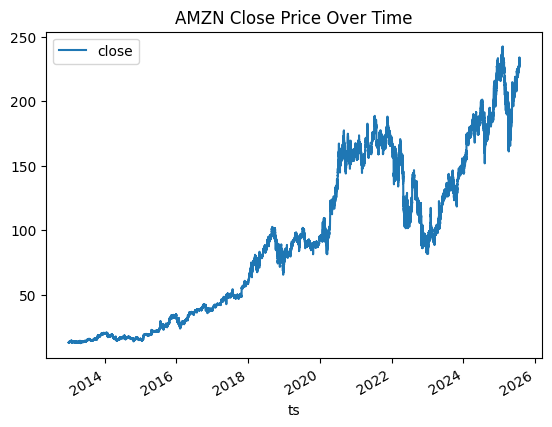

In [5]:
df.plot(x='ts', y='close', title='AMZN Close Price Over Time')

<Axes: title={'center': 'AMZN Volume Over Time'}, xlabel='ts'>

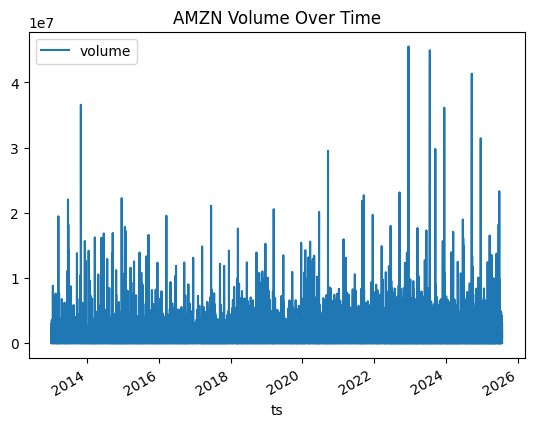

In [6]:
df.plot(x='ts', y='volume', title='AMZN Volume Over Time')

<Axes: >

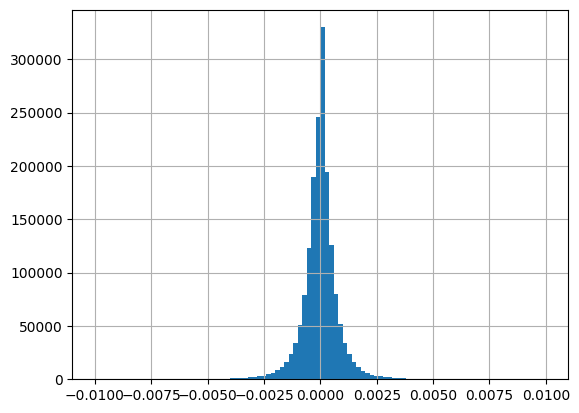

In [7]:
df['returns'] = df['close'].pct_change()
df['returns'].hist(bins=100, range=(-0.01, 0.01))


<Axes: title={'center': 'Volatility (Absolute Returns)'}>

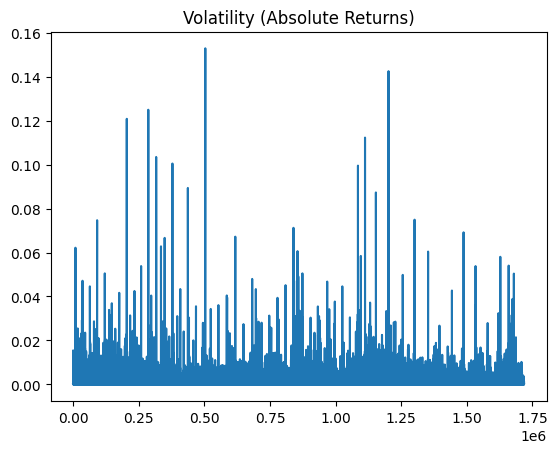

In [8]:
df['returns'].abs().plot(title='Volatility (Absolute Returns)')

In [22]:
TSLA = data_dir + 'equity/TSLA.parquet'
NVDA = data_dir + 'equity/NVDA.parquet'
FX = data_dir + 'fx/USDCNH.parquet'
VIX = data_dir + 'index/VIX.parquet'
FUTURES_CRUDE = data_dir + 'futures/CL.parquet'
FUTURES_USD = data_dir + 'futures/DX.parquet'
ICLN = data_dir + 'etf/ICLN.parquet'
BTC = data_dir + 'crypto/BTC.parquet'

files = [TSLA, FX, VIX, FUTURES_CRUDE, FUTURES_USD, ICLN, BTC]
df_list = [pd.read_parquet(f, engine='fastparquet') for f in files]
all_data = pd.concat(df_list).sort_values(by=['ts', 'symbol'])

<Axes: title={'center': 'VIX (Fear Gauge)'}, xlabel='ts'>

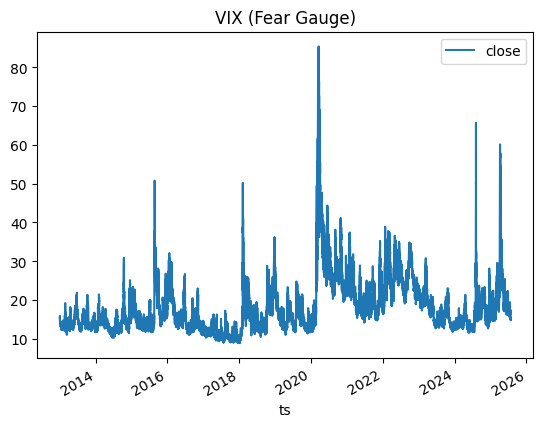

In [23]:
vix = all_data[all_data['symbol'] == 'VIX']
vix.plot(x='ts', y='close', title='VIX (Fear Gauge)')

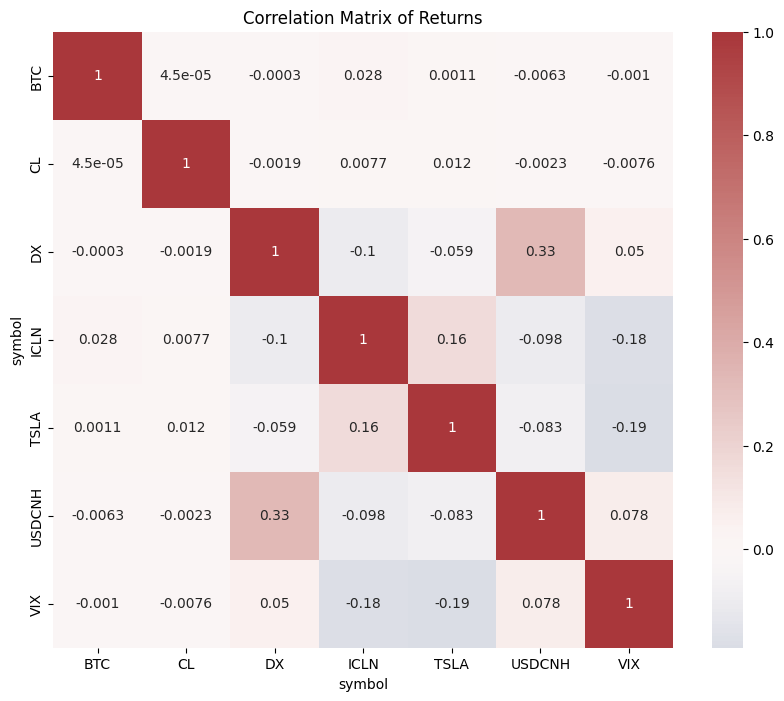

In [24]:
symbols_to_compare = ['TSLA', 'VIX', 'USDCNH', 'CL', 'DX', 'ICLN']
all_data['returns'] = all_data.groupby('symbol')['close'].pct_change()
pivot_returns = all_data.pivot(index='ts', columns='symbol', values='returns')
corr_matrix = pivot_returns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0)
plt.title('Correlation Matrix of Returns')
plt.show()